In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
# print(iris.keys())

X = iris['data']
print(X.shape)
feature_names = iris['feature_names']
print(feature_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


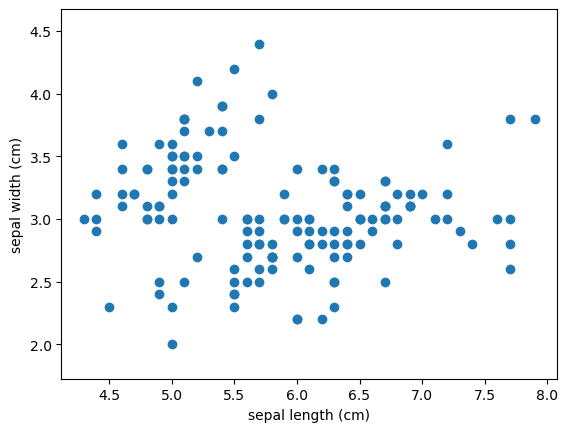

In [2]:
plt.figure()
plt.plot(X[:,0],X[:,1],'o')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.axis('equal');

In [3]:
from sklearn.cluster import KMeans
import numpy as np

In [4]:
X[0:4,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2]])

In [5]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
print(kmeans.labels_)
print(kmeans.predict(X[0:4,:]))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
[0 0 0 0]


C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

In [6]:
print(kmeans.cluster_centers_)

[[5.00566038 3.36981132 1.56037736 0.29056604]
 [6.30103093 2.88659794 4.95876289 1.69587629]]


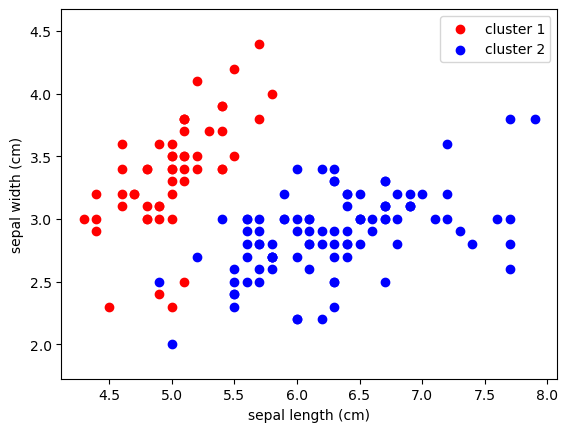

In [7]:
color_ls = ['r','b','g','m','y','c']
plt.figure()
for i, j in enumerate(np.unique(kmeans.labels_)):
    plt.scatter(X[kmeans.labels_ == j, 0], X[kmeans.labels_ == j, 1],
                c = color_ls[j], label = 'cluster '+str(j+1))
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.axis('equal');

In [8]:
print(kmeans.score(X))

-152.34795176035792


Manually calculate the cost value

In [9]:
Xp = np.zeros(X.shape)
cX = kmeans.cluster_centers_
for i,i_k in enumerate(kmeans.labels_):
    Xp[i,:] = cX[i_k,:]
print(np.sum((Xp-X)**2))

152.34795176035792


## Additional analyses
* Visualize the clustering results in PCA space (2D)
* Try different K and compare the clustering result plot and cost function

### Visualize in PCA space

In [10]:
from sklearn.decomposition import PCA

PCA_model = PCA(n_components=2)
PCA_model.fit(X)
z = PCA_model.transform(X)

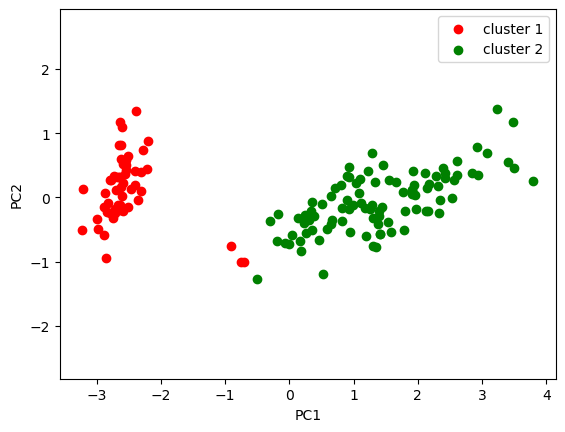

In [11]:
color_ls = ['r','g','b','m','y','c']
plt.figure()
for i, j in enumerate(np.unique(kmeans.labels_)):
    plt.scatter(z[kmeans.labels_ == j, 0], z[kmeans.labels_ == j, 1],
                c = color_ls[j], label = 'cluster '+str(j+1))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.axis('equal');